# Entrega Final Dente Alan - Analisis Salario de Trabajadores IT

## 1. Objetivo

#### Desarrollar un modelo de predicción para evaluar la probabilidad del salario a percibir debido a varias variables.

### 1.1 Contexto Laboral

En un mundo donde la información fluye cada vez mas rápido, las personas que trabajan con datos se elevan como una guía para las empresas. Desde el amanecer de la era digital, la humanidad ha acumulado más información de la que jamás podría haber imaginado, y con ello, un nuevo reto surgió: ¿Cómo encontrar sentido en ese caos? Aquí es donde entra el labor de los profecionales de datos, el explorador moderno que navega por este océano buscando patrones ocultos, conexiones insospechadas y conocimientos que transforman industrias enteras.

### 1.2 Contexto analítico

Para poder desarrollar el modelo, el data set cuenta con un rango aproximado de 740, las variables tomadas fueron 28:

| ID | Variable | Descripción |
|----|----------|-------------|
|1| Job Title| Titulo del trabajo| 
|2| Salary Estimate | Salario Estimado|
|3| Job Description | Descripción del trabajo| 
| 4|  Rating | Ratio del trabajo | 
| 5 |  Company Name | Nombre de la compañia | 
| 6 |  Location | Localidad del trabajador | 
| 7 |  Headquarters | Localidad de las Oficinas centrales | 
| 8 |  Size | Tamaño de la compañia | 
| 9 |  Founded | Año de fundación de la compañia | 
| 10 |  Type of ownership | Tipo de compañia | 
| 11 |  Industry | Tipo de industria de la compañia | 
|  12 |  Sector | Sector industrial de la compañia | 
| 13 |  Revenue | Ingreso de la compañia | 
| 14 |  Competitors | Competencias de la compañia | 
| 15 |  Hourly | ¿Pago por Hora? | 
| 16 |  Employer_provided | Beneficios provistos | 
| 17 |  Min_salary | Salario minimo del empleo medido en Miles de U$D| 
| 18 |  Max_salary | Salario Maximo del empleo medido en Miles de U$D | 
| 19 |  Avg_salary | Salario promedio del empleo medido en Miles de U$D | 
| 20 |  company_txt | Nombre de la compañia | 
| 21 |  Job_state | Estado de la compañia | 
| 22 |  Same_state | ¿Trabajador en mismo Estado que la compañia? | 
| 23 |  Age | Edad del trabajador | 
| 24 |  Python_yn | Conocimiento de Python | 
| 25 |  R_yn| Conocimiento de R| 
| 26 |  Spark | Conocimiento de Spark| 
| 27 |  Aws | Conocimiento de Aws| 
| 28 |  Excel| Conocimiento de Excel| 

#### Importamos las bibliotecas a usar

In [86]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
mpl.style.use('bmh')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2. Importamos el DataSet

In [55]:
# Leer el archivo CSV
df = pd.read_csv('salary_data.csv', sep=',')

## 3. Análisis del dataset

### 3.1 Análisis de Nulos

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          742 non-null    object 
 1   Salary Estimate    742 non-null    object 
 2   Job Description    742 non-null    object 
 3   Rating             742 non-null    float64
 4   Company Name       742 non-null    object 
 5   Location           742 non-null    object 
 6   Headquarters       742 non-null    object 
 7   Size               742 non-null    object 
 8   Founded            742 non-null    int64  
 9   Type of ownership  742 non-null    object 
 10  Industry           742 non-null    object 
 11  Sector             742 non-null    object 
 12  Revenue            742 non-null    object 
 13  Competitors        742 non-null    object 
 14  hourly             742 non-null    int64  
 15  employer_provided  742 non-null    int64  
 16  min_salary         742 non

In [30]:
print(df.isnull().sum())

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
hourly               0
employer_provided    0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
same_state           0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
dtype: int64


### 3.2 Estadisticas del dataset

In [31]:
df.describe()

,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,1837.154987,0.032345,0.022911,74.068733,127.183288,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911
std,0.801210,497.183763,0.177034,0.149721,31.869282,46.909006,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812
min,-1.000000,-1.000000,0.000000,0.000000,10.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Analisis exploratorio de datos (EDA)

#### La variable a seguir es el **Salario Promedio**
Analisis de datos estadisticos

In [32]:
variable_obj = df['avg_salary']
variable_obj.describe().round(0)

count    742.0
mean     101.0
std       39.0
min       14.0
25%       74.0
50%       98.0
75%      122.0
max      254.0
Name: avg_salary, dtype: float64

Histograma del mismo

Text(0.5, 1.0, 'Distribución del Salario Promedio')

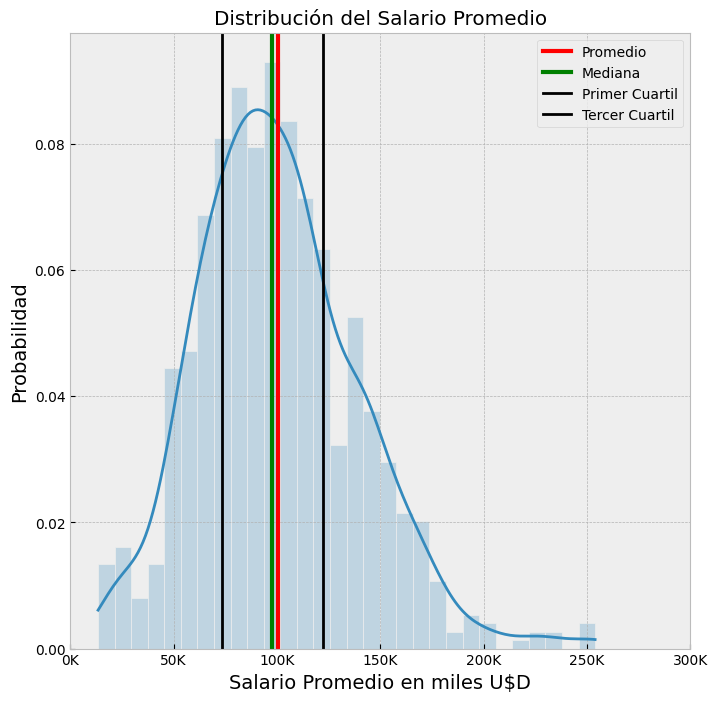

In [33]:
media = variable_obj.mean()
mediana = variable_obj.median()
primer_cuartil = variable_obj.quantile(0.25)
tercer_cuartil = variable_obj.quantile(0.75)

plt.figure(figsize=(8,8))
sns.histplot(data = df,
             x = 'avg_salary',
             bins = 30,            
             alpha = 0.25,
             kde = True,
             stat='probability')
plt.axvline(x = media, 
            color = 'red', 
            linestyle = '-', 
            label = 'Promedio',
            linewidth = 3)
plt.axvline(x = mediana, 
            color = 'green', 
            linestyle = '-', 
            label = 'Mediana',
            linewidth = 3)
plt.axvline(x = primer_cuartil, 
            color = 'black', 
            linestyle = '-', 
            label = 'Primer Cuartil',
            linewidth = 2)
plt.axvline(x = tercer_cuartil, 
            color = 'black', 
            linestyle = '-', 
            label = 'Tercer Cuartil',
            linewidth = 2)
plt.legend()
plt.xlabel('Salario Promedio en miles U$D', fontsize=14)
plt.ylabel('Probabilidad', fontsize=14)
current_ticks = plt.xticks()[0]
plt.xticks(current_ticks, [f'{int(tick)}K' for tick in current_ticks])
plt.title('Distribución del Salario Promedio')

- Se puede verificar que el **salario promedio** tiene una distribución asimetrica positiva, teniendo su mediana y media muy cercanos a 100k
- Esto indica que la mayor probabilidad está es que el salario sea de 100k, por otro lado hay muy pocos salarios muy altos cercanos a 250k

## 5. Revisión de variables a comparar

#### Reviso los datos de **age**, la misma suele tener bastantes datos atípicos

In [34]:
print(df[['age']]) 

     age
0     47
1     36
2     10
3     55
4     22
..   ...
737  190
738   14
739   36
740   -1
741   53

[742 rows x 1 columns]


Como esperaba, la variable *age* tiene varios valores atípicos, como edades de *-1*, *190*. Realizo el primer filtrado de datos por lo cual tomaré como criterio, las edades entre 18 años y 65 años.

In [35]:
df1 = df[(df['age']>=18) & (df['age']<=65)]
df1 = df1.copy()

## 6. Correlación de variables a analizar

Ahora analizaré la correlación entre las variables que quiero analizar

Primero convierto en valores numéricos las variables String que deseo analizar, para esto utilizo *Encoder*

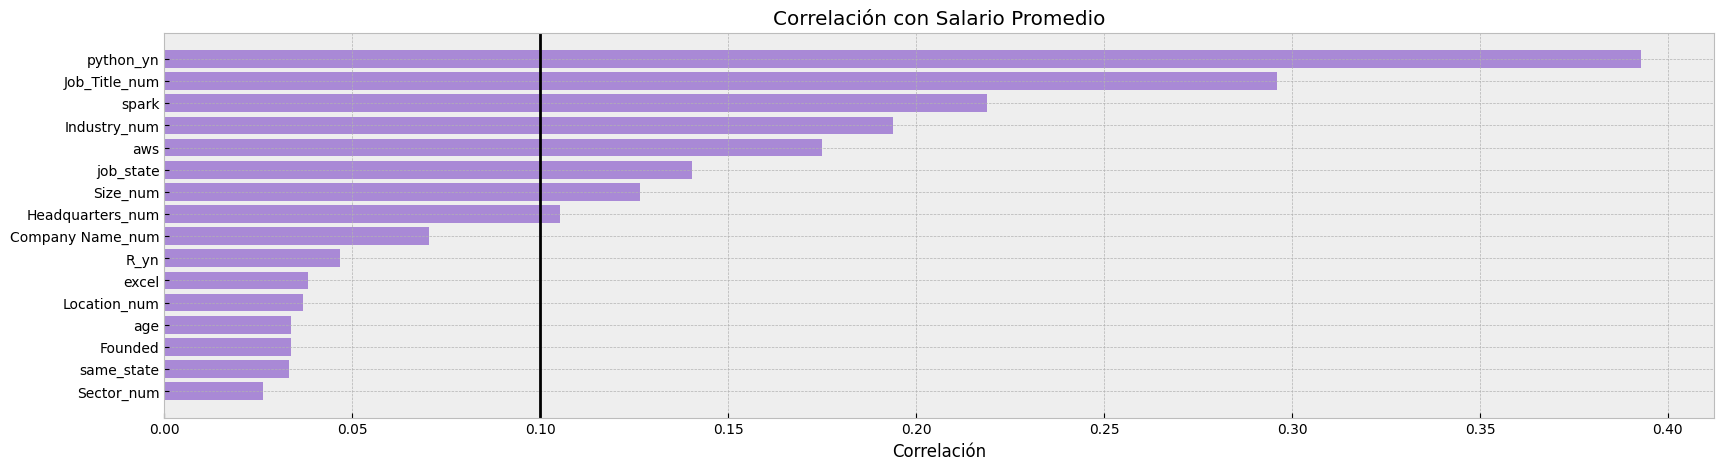

In [36]:
# codifico numéricamente las categorias
label_encoder = LabelEncoder()
df1['Job_Title_num'] = label_encoder.fit_transform(df1['Job Title'])
df1['Company Name_num'] = label_encoder.fit_transform(df1['Company Name'])
df1['Location_num'] = label_encoder.fit_transform(df1['Location'])
df1['Headquarters_num'] = label_encoder.fit_transform(df1['Headquarters'])
df1['Sector_num'] = label_encoder.fit_transform(df1['Sector'])
df1['Industry_num'] = label_encoder.fit_transform(df1['Industry'])
df1['Size_num'] = label_encoder.fit_transform(df1['Size'])
df1['job_state'] = label_encoder.fit_transform(df1['job_state'])
df1['same_state'] = label_encoder.fit_transform(df1['same_state'])

# Análisis de correlación
df_numerico = df1.select_dtypes(include=['float64', 'int64'])
correlacion = df_numerico.corr()
 
correlacion_obj = correlacion['avg_salary']
 
correlacion_obj = abs(correlacion_obj)
 
columnas_a_excluir = ['avg_salary','hourly','employer_provided','min_salary','max_salary','Rating']

correlacion_obj = correlacion_obj.drop(columns=columnas_a_excluir, index=columnas_a_excluir)

correlacion_obj = correlacion_obj.sort_values(ascending=False)

# Grafico variables más correlacionadas
correlacion_obj_graficar = correlacion_obj[0:30]
plt.figure(figsize=(20, 5)) 
plt.barh(correlacion_obj_graficar.index, 
         correlacion_obj_graficar.values,
         color = '#A989D6')
plt.xlabel('Correlación')
plt.title('Correlación con Salario Promedio')
plt.gca().invert_yaxis()
plt.axvline(x = 0.10, 
            color = 'black', 
            linestyle = '-', 
            linewidth = 2)
plt.show()

> Del analisis del grafico anterior, podemos ver que las variables que mas se correlacionan con el salario promedio son:

1. Conocimiento de Python
2. El titulo de trabajo
3. Conocimiento de spark
4. La industria
5. conocimiento de aws
6. Estado del trabajo
7. Tamaño de la empresa
8. Localidad de la empresa

## 7. Analisis de Variables

### 7.1 Conocimiento de python

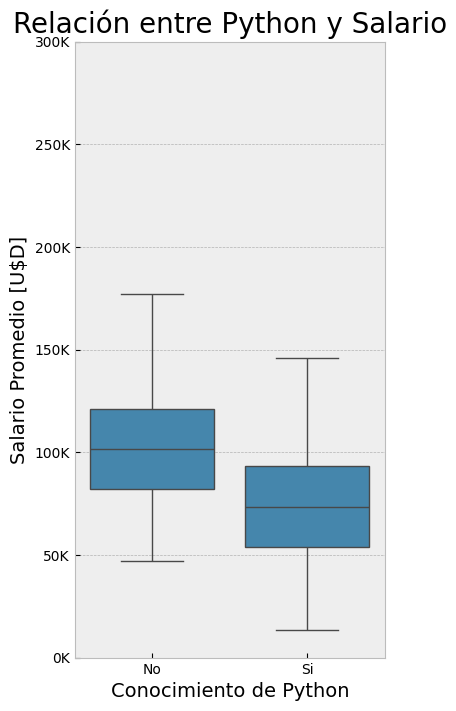

In [37]:
plt.figure(figsize=(4,8))
df2 = df1
df2['python_yn'] = df2['python_yn'].replace({0: 'Si', 1: 'No'})
sns.boxplot(data = df1,
            x = 'python_yn',
            y = 'avg_salary',
            showfliers = False)

plt.title('Relación entre Python y Salario', fontsize=20)
plt.xlabel('Conocimiento de Python', fontsize=14)
plt.ylabel('Salario Promedio [U$D]', fontsize=14)
plt.yticks(current_ticks, [f'{int(tick)}K' for tick in current_ticks])
plt.show()

> Se puede observar que el conocimiento en python, aumenta el promedio de salarios de los trabajadores en IT

### 7.2 Relación entre Titulo de trabajo y Salario

In [38]:
#Obtención de trabajos mas frecuentes
df2 = df
conteo = df2['Job Title'].value_counts()
frecuentes = conteo[conteo >= 7].index
df_filtrado = df2[df2['Job Title'].isin(frecuentes)]

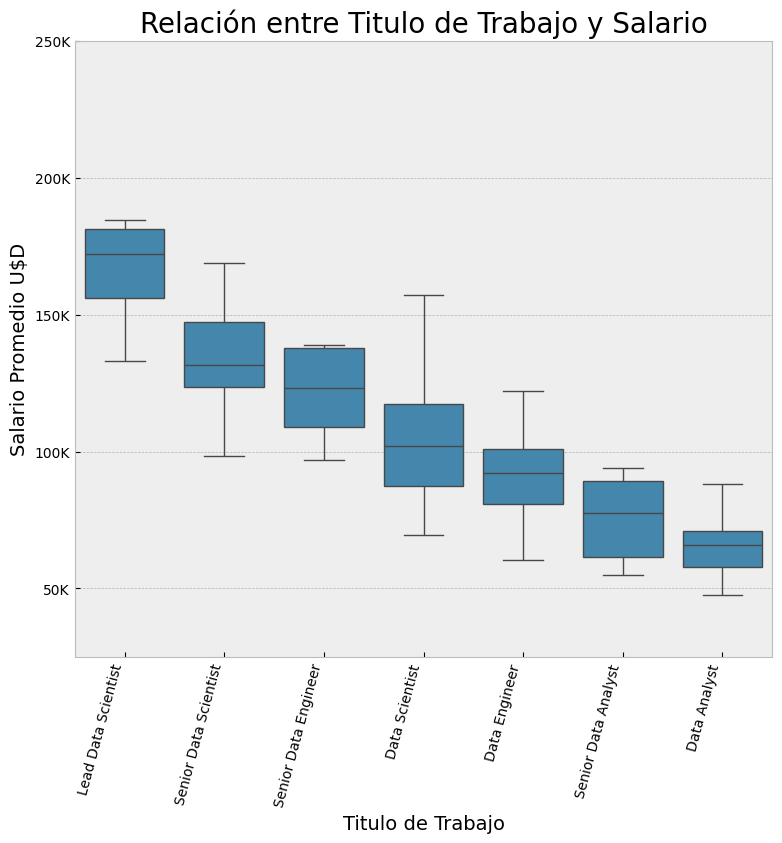

In [39]:
promedios = df_filtrado.groupby('Job Title')['avg_salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(9,8))
sns.boxplot(data = df_filtrado,order=promedios.index,
            x = 'Job Title',
            y = 'avg_salary',
            showfliers = False)

plt.title('Relación entre Titulo de Trabajo y Salario', fontsize=20)
plt.xlabel('Titulo de Trabajo', fontsize=14)
plt.ylabel('Salario Promedio U$D', fontsize=14)
plt.xticks(rotation=75, ha='right')
plt.yticks(current_ticks, [f'{int(tick)}K' for tick in current_ticks])
plt.ylim(25, 250)
plt.show()

> Desde el grafico observamos que el trabajo con mayor salario es el **Lead Data Scientist**. 

> Mientras que el trabajo con menor salario es **Data Analyst**

### 7.3 Relación entre el Sector y el salario

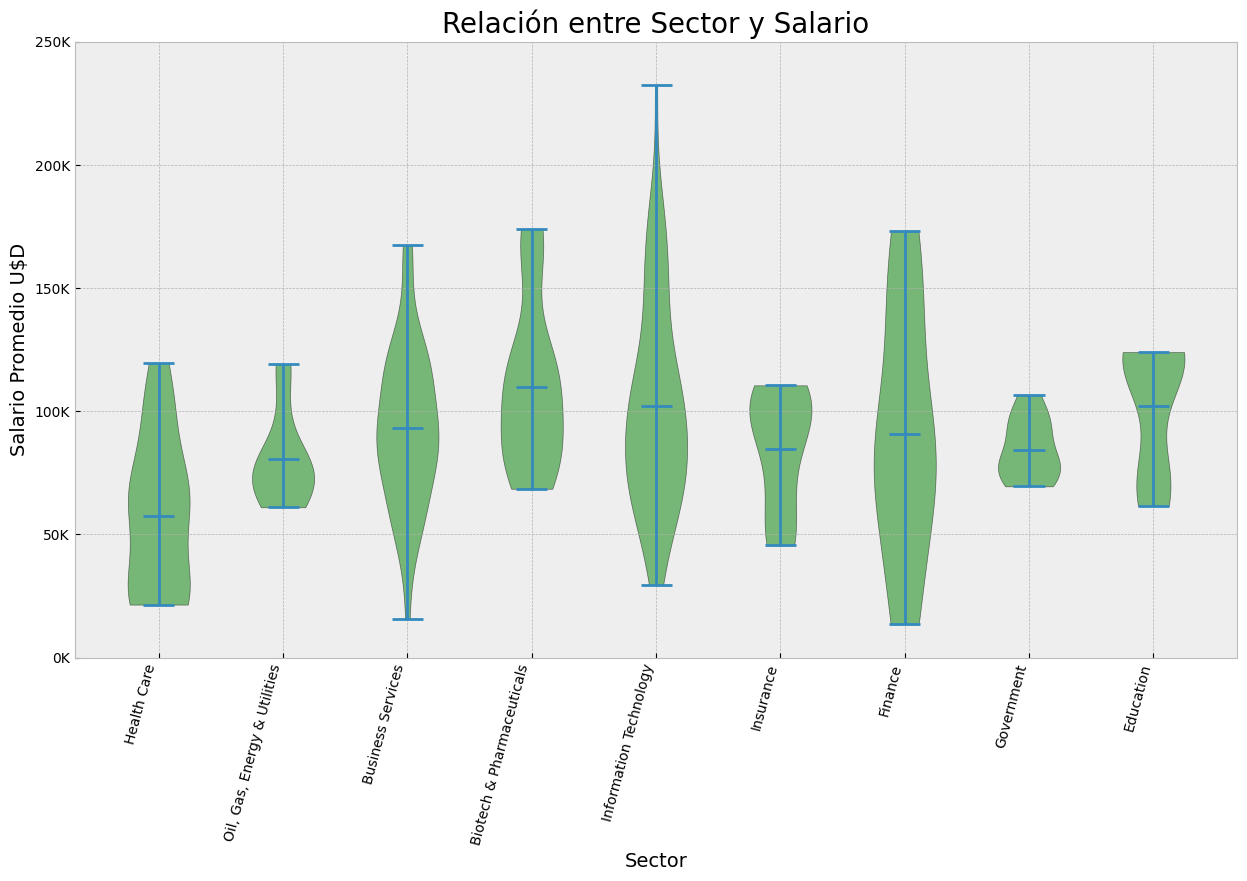

In [40]:
# Sectores mas frecuentes
conteo2 = df1['Sector'].value_counts()
frecuentes2 = conteo2[conteo2 >= 10].index

df_filtrado2 = df1[df1['Sector'].isin(frecuentes2)]

fig, ax = plt.subplots(figsize=(15,8))

# Agrupa los datos de 'avg_salary' por 'Sector' y pásalos como listas para violinplot
sector_labels = df_filtrado2['Sector'].unique()
salary_data = [df_filtrado2[df_filtrado2['Sector'] == sector]['avg_salary'].values for sector in sector_labels]

violins = ax.violinplot(salary_data, showmeans=True, showmedians=False, showextrema=True)

for violin in violins['bodies']:
    violin.set_facecolor('green')
    violin.set_edgecolor('black')
    violin.set_alpha(0.5)

# Ajusta las etiquetas del eje x a los sectores
ax.set_xticks(range(1, len(sector_labels) + 1))
ax.set_xticklabels(sector_labels, rotation=75, ha='right')

plt.title('Relación entre Sector y Salario', fontsize=20)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Salario Promedio U$D', fontsize=14)

# Define los ticks actuales del eje y (puedes ajustar según tus datos)
current_ticks = ax.get_yticks()
plt.yticks(current_ticks, [f'{int(tick)}K' for tick in current_ticks])

plt.ylim(0, 250)
plt.show()

> Se puede analizar desde el grafico que el sector con mas alto salario es bastante parecido para cada sector, aunque, el menor promedio es **Health Care**. Por otro lado se puede ver que en el sector de **Finance** existe una gran variedad de salarios, mientras que en el sector de **Information Technology** tiene valores altos de salarios.

### 7.4 Relacion entre la industria y los salarios

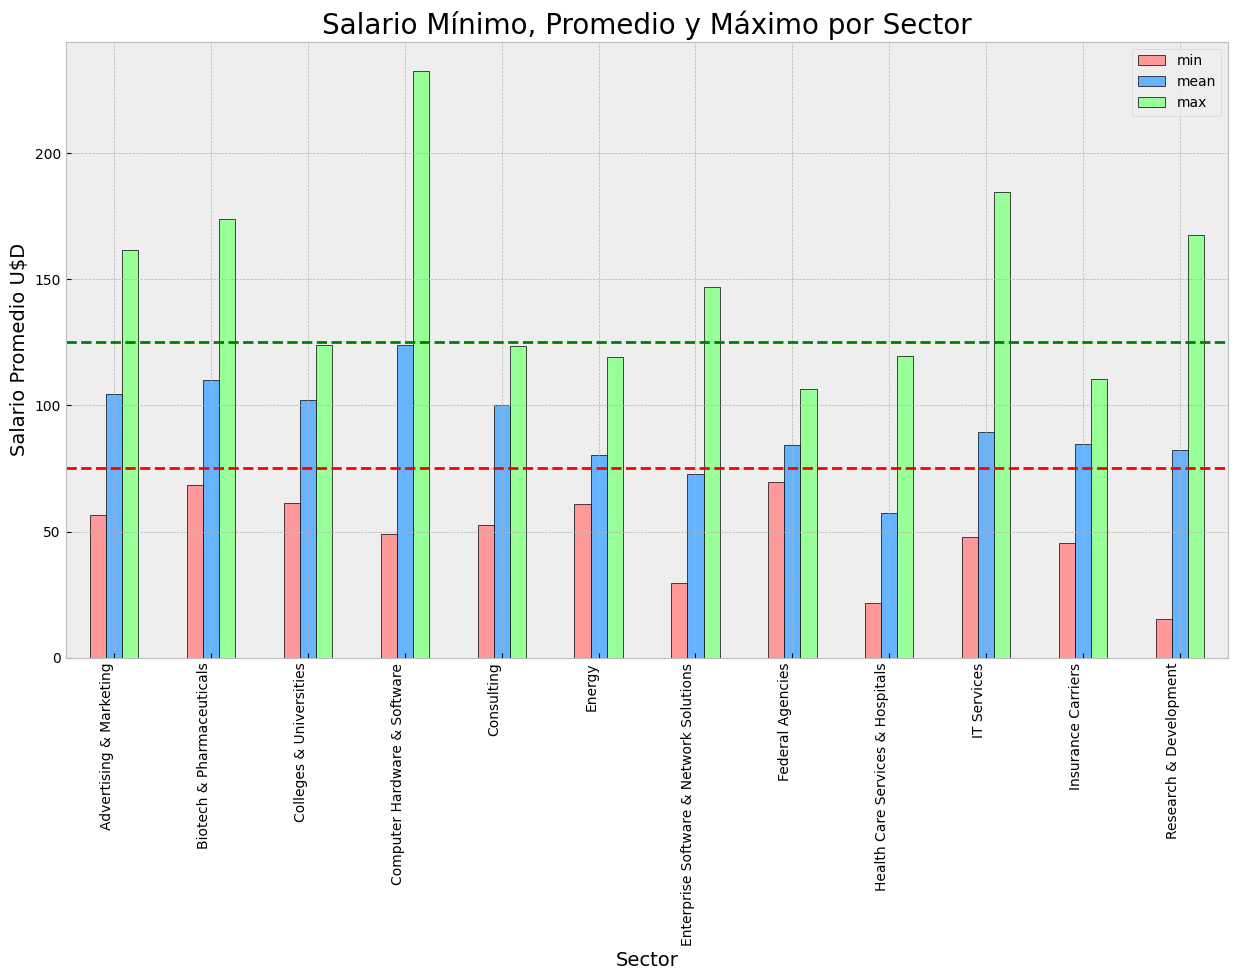

In [41]:
# Industrias mas frecuentes
conteo3 = df1['Industry'].value_counts()
frecuentes3 = conteo3[conteo3 >= 10].index

df_filtrado3 = df1[df1['Industry'].isin(frecuentes3)]

# Calcular los valores mínimo, promedio y máximo por sector
df3 = df_filtrado3.groupby('Industry')['avg_salary'].agg(['min', 'mean', 'max'])

# Crear el gráfico de barras para los valores alto, promedio y bajo
plt.figure(figsize=(15,8))
df3.plot(kind='bar', ax=plt.gca(), color=['#ff9999','#66b3ff','#99ff99'], edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Salario Mínimo, Promedio y Máximo por Sector', fontsize=20)
plt.xlabel('Sector', fontsize=14)
plt.ylabel('Salario Promedio U$D', fontsize=14)

# Rotar las etiquetas del eje x para que se vean mejor
plt.xticks(rotation=90, ha='right')
plt.axhline(y=75, color='red', linestyle='--', linewidth=2, label='75K')
plt.axhline(y=125, color='green', linestyle='--', linewidth=2, label='125K')
plt.show()

> Para el grafico anterior, observamos que los valores mas bajos se encuentran en **Health Care Services & Hospitals**, mientras que los valores mas altos están en **Computer Hardware & Software**. Pero para la gran mayoria de las industrias mostradas, el valor promedio se mantiene en un rango de entre 75K y 125k 

### 7.5 Relación entre el Salario y al Estado donde vive respecto a las oficinas centrales

La relación es la siguiente:

0 = No vive en el mismo Estado

1 = Vive en el mismo Estado

Para esto haré un grafico de cajas, que es lo que mas puede representar estos valores

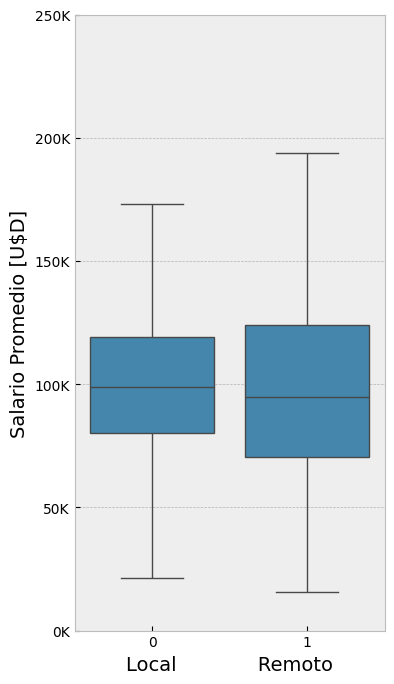

In [42]:
plt.figure(figsize=(4,8))
df['python_yn'] = df['same_state'].replace({0: 'Si', 1: 'No'})
sns.boxplot(data = df,
            x = 'same_state',
            y = 'avg_salary',
            showfliers = False)


plt.xlabel('Local             Remoto', fontsize=14)
plt.ylabel('Salario Promedio [U$D]', fontsize=14)
plt.yticks(current_ticks, [f'{int(tick)}K' for tick in current_ticks])
plt.show()

> Podemos observar que no existe una relación directa entre trabajar en el mismo Estado o no que las oficinas centrales

## 8. Evaluación de relación entre categorias y salario

### 8.1 Metodo de filtro: Chi-cuadrado

#### Al tener bastante variables categoricas, aplico el test de Chi-cuadrado para evaluar que categorías están mas relacionadas con el salario

A continuación codifico numéricamente las categorias

In [53]:
label_encoder = LabelEncoder()
df1 = df
df1['Job_Title_num'] = label_encoder.fit_transform(df1['Job Title'])
df1['Company Name_num'] = label_encoder.fit_transform(df1['Company Name'])
df1['Location_num'] = label_encoder.fit_transform(df1['Location'])
df1['Headquarters_num'] = label_encoder.fit_transform(df1['Headquarters'])
df1['Sector_num'] = label_encoder.fit_transform(df1['Sector'])
df1['Industry_num'] = label_encoder.fit_transform(df1['Industry'])
df1['Size_num'] = label_encoder.fit_transform(df1['Size'])
df1['job_state'] = label_encoder.fit_transform(df1['job_state'])
df1['same_state'] = label_encoder.fit_transform(df1['same_state'])


In [54]:
X = df1[['Job_Title_num', 'Company Name_num', 'Location_num', 'Headquarters_num', 'Sector_num', 'Industry_num', 'Size_num', 'job_state', 'same_state']]

df1['Promedio Salario'] = pd.cut(df1['avg_salary'], bins=3, labels=[0, 1, 2])

y = df1['Promedio Salario']

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X, y)

SelectKBest(k='all', score_func=<function chi2 at 0x0000016539174AE0>)

In [45]:

chi2_scores = pd.DataFrame({'Característica': X.columns, 'Puntuación Chi2': chi2_selector.scores_})
chi2_scores_sorted = chi2_scores.sort_values(by='Puntuación Chi2', ascending=False)
print(chi2_scores_sorted)

     Característica  Puntuación Chi2
0     Job_Title_num      1362.535994
7         job_state       193.438350
1  Company Name_num       191.066723
5      Industry_num       135.960559
3  Headquarters_num        35.061285
2      Location_num        21.219388
4        Sector_num         9.928912
8        same_state         1.693525
6          Size_num         0.823788


#### A partir del resultado anterior, podemos clasificar en importancia de relación con el salario de la siguiente forma:
- Job_Title (1362)
- Job_state (193)
- Company Name (191)
- Industry (136)

#### Los dos siguientes tienen una relación baja-moderada con el salario

- Headquarters
- Location
- Sector

#### El resto de las variables tienen una puntuación muy baja, por lo que los descarto para el analisis

## 9. Utilización de modelos predictivos

### 9.1 Modelado con Regresión Lineal

In [93]:
X = df1[['Job_Title_num', 'Company Name_num', 'Location_num', 'Headquarters_num', 
        'Industry_num', 'job_state']]

y = df1['Promedio Salario']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R²): {r2}")
print(f"Error absoluto medio (MAE): {mae}")


coeficientes = pd.DataFrame({'Característica': X.columns, 'Coeficiente': modelo.coef_})
print(coeficientes)

Error cuadrático medio (MSE): 0.2907846665149627
Coeficiente de determinación (R²): 0.0321273791156389
Error absoluto medio (MAE): 0.4954097759806778
     Característica  Coeficiente
0     Job_Title_num     0.001566
1  Company Name_num     0.000414
2      Location_num    -0.000282
3  Headquarters_num     0.000205
4      Industry_num     0.000661
5         job_state    -0.008248


#### En base a los resultados obtenidos, un modelo de regresión lineal, no está capturando bien la relación entre las variables, por lo que no es un buen modelo para para predecir salarios basándose en las caracteristicas que estoy usando.

### 9.2 Analisis por Arbol de decisión

In [92]:
X = df1[['Job_Title_num', 'Company Name_num', 'Location_num', 'Headquarters_num', 
        'Industry_num', 'job_state']]

y = df1['Promedio Salario']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

arbol_regresor = DecisionTreeRegressor(random_state=42)

arbol_regresor.fit(X_train, y_train)

y_pred = arbol_regresor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R²): {r2}")
print(f"Error absoluto medio (MAE): {mae}")


Error cuadrático medio (MSE): 0.1342281879194631
Coeficiente de determinación (R²): 0.553223388305847
Error absoluto medio (MAE): 0.1342281879194631


#### El metodo de Arbol de decisión captura mejor la relación entre las variables. por lo que puede explicar el 55.3% de la variabilidad en los salarios.

### 9.2.1 Ahora grafico el árbol de decisión para visualizar y entender mejor como toma decisiones.

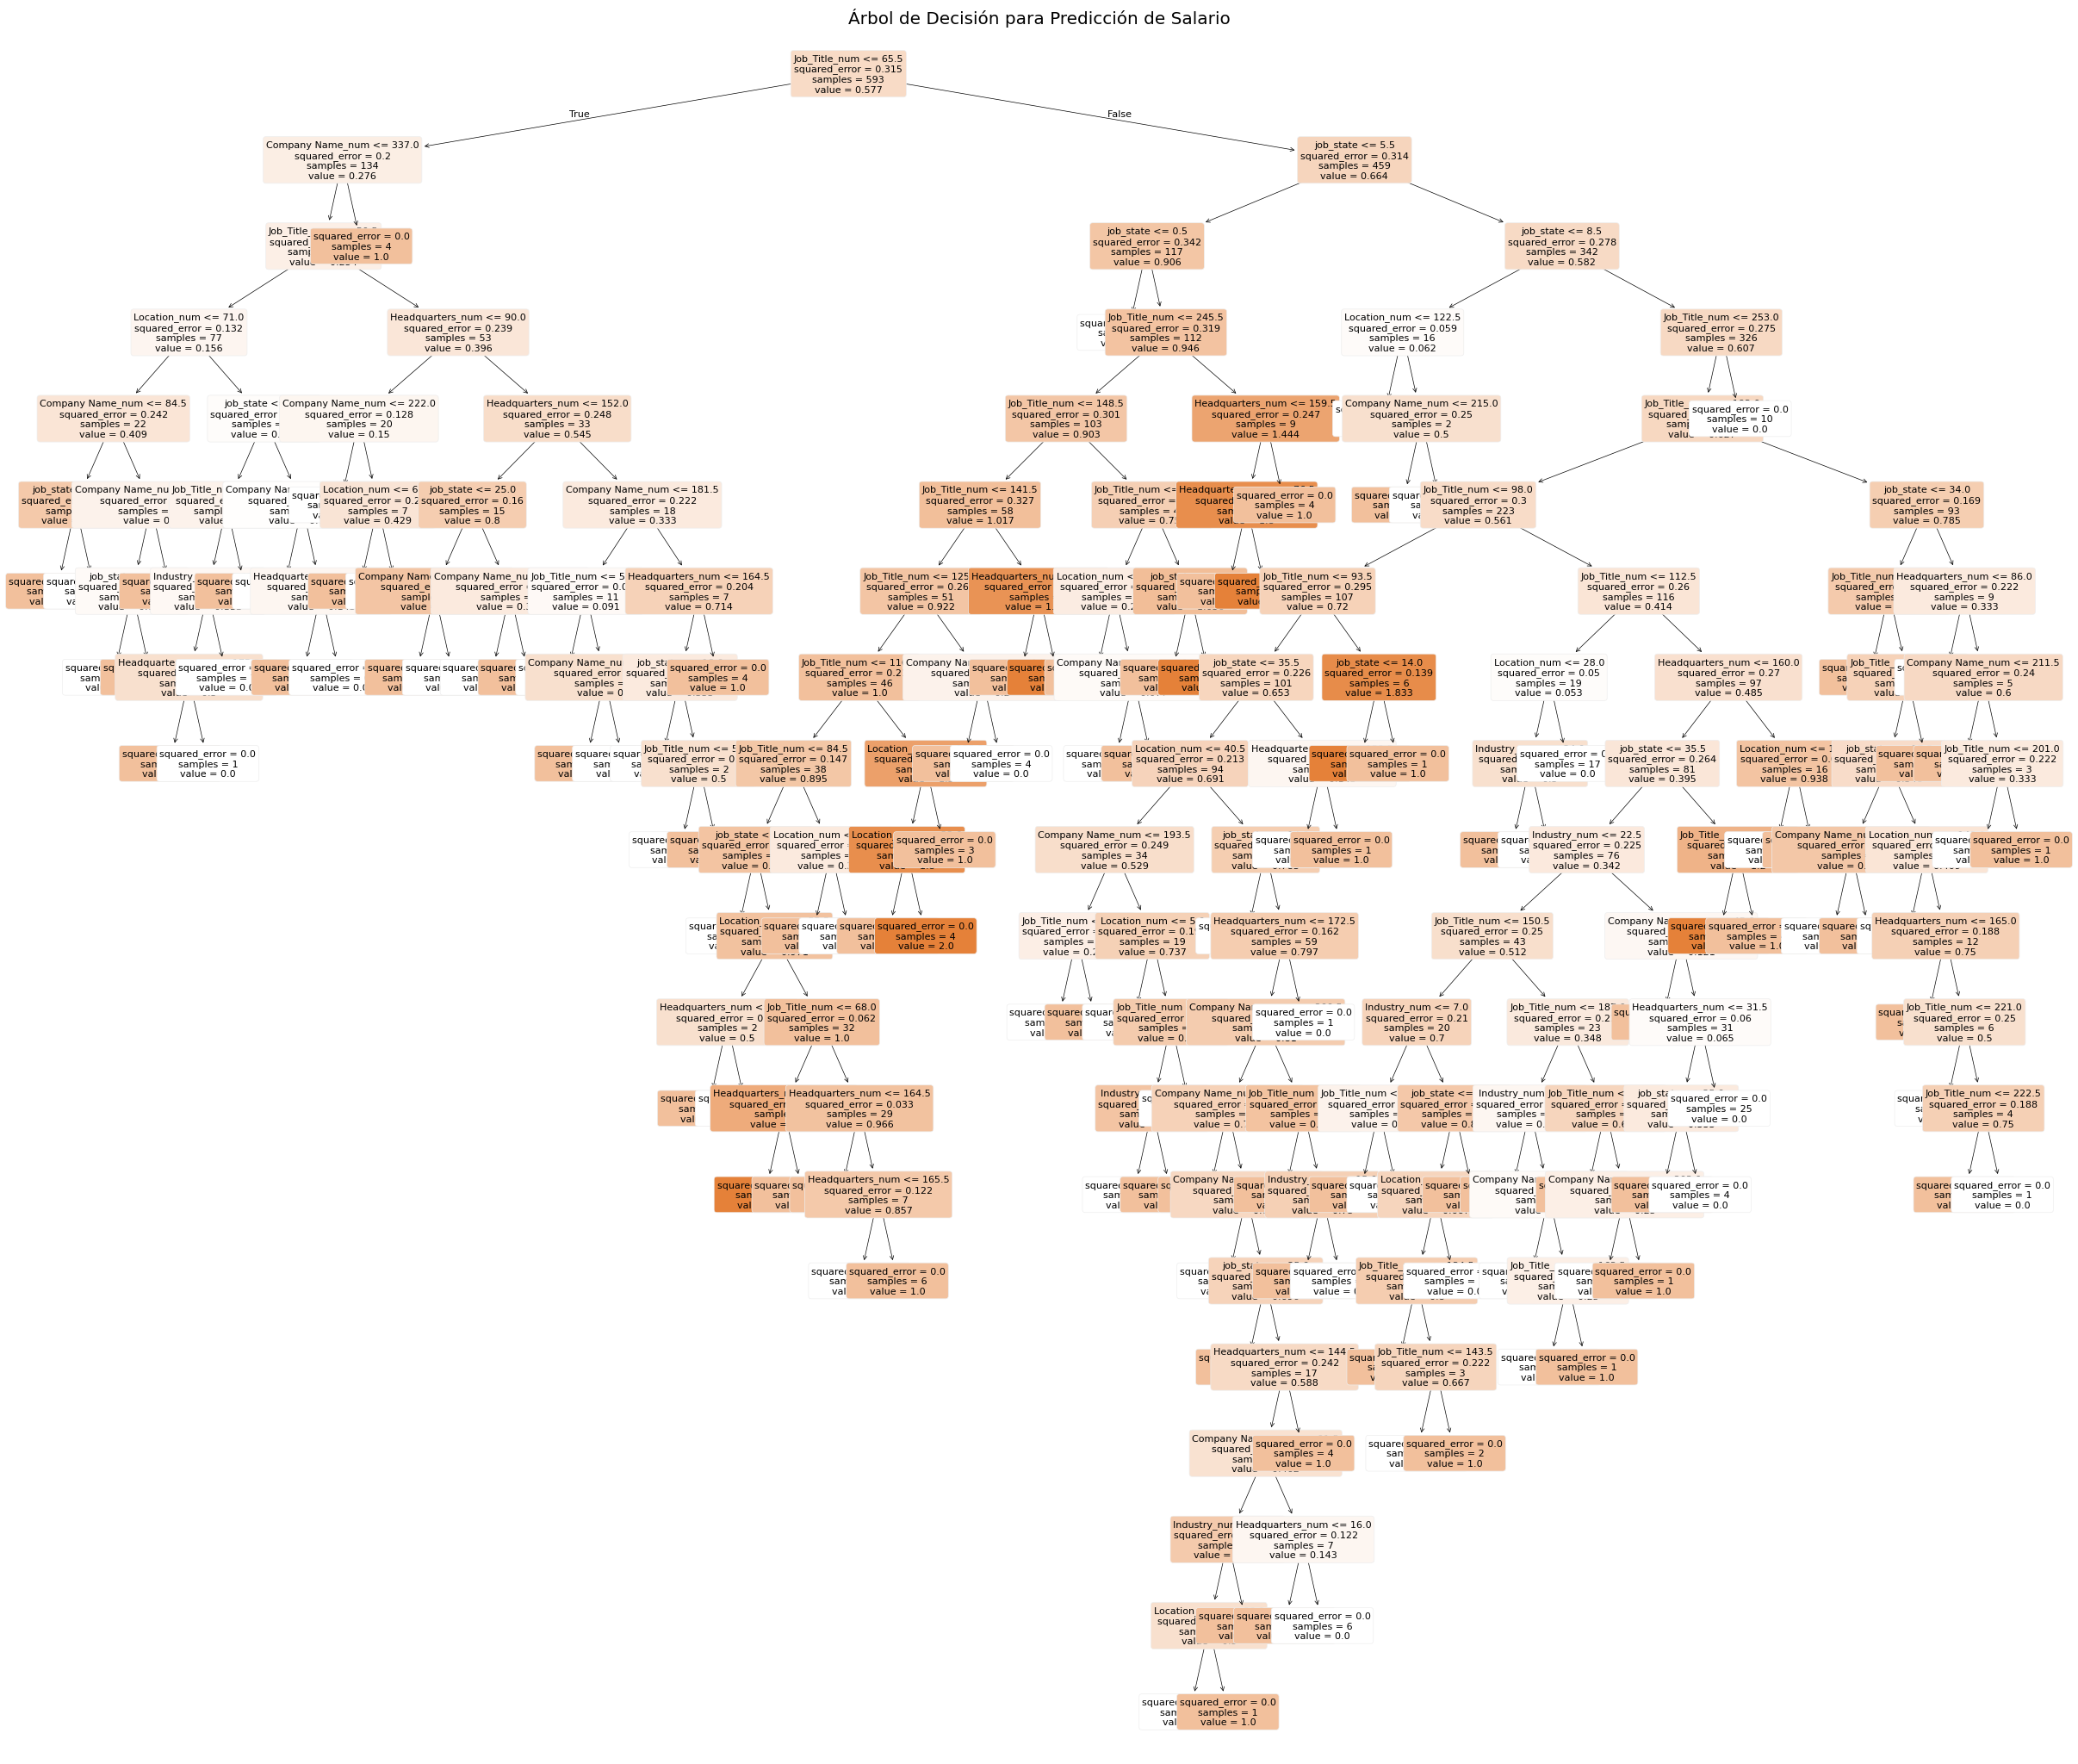

In [57]:


plt.figure(figsize=(30, 26))
plot_tree(arbol_regresor, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión para Predicción de Salario")
plt.show()

### 9.3 Modelado con Random Forest

In [90]:
# Importar las librerías necesarias


# Características y variable objetivo
X = df1[['Job_Title_num', 'Company Name_num', 'Location_num', 'Headquarters_num', 
        'Industry_num', 'job_state']]
y = df1['Promedio Salario']

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de Random Forest
random_forest_model = RandomForestRegressor(random_state=42)

# Entrenar el modelo
random_forest_model.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = random_forest_model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R²): {r2}")
print(f"Error absoluto medio (MAE): {mae}")


# Importancia de características
importancias = random_forest_model.feature_importances_
import pandas as pd
import numpy as np

# Crear un DataFrame para mostrar la importancia de las características
importancias_df = pd.DataFrame({'Característica': X.columns, 'Importancia': importancias})
importancias_df = importancias_df.sort_values(by='Importancia', ascending=False)

print("\nImportancia de las características:")
print(importancias_df)


Error cuadrático medio (MSE): 0.09285033557046979
Coeficiente de determinación (R²): 0.7119381917272221
Error absoluto medio (MAE): 0.2238255033557047

Importancia de las características:
     Característica  Importancia
0     Job_Title_num     0.344322
1  Company Name_num     0.162082
5         job_state     0.151413
3  Headquarters_num     0.118998
4      Industry_num     0.112769
2      Location_num     0.110415


> En este caso el Random Forest captura mejor la relación entre los datos y tiene un menor error

## 11. Resultados obtenidos de los metodos utilizados

| ID | Modelo | MAE | MSE | R² |
|----|----------|-----|-----|----|
|1| Regresión Lineal| 0.495 | 0.291 | 0.032 |
|2| Árbol de Decisión | 0.134 | 0.134 | 0.553 |
|3| Random Forest| 0.224 | 0.093 | 0.712 |

## 12. Conclusiones

### 12.1 Según variables

Las variables mas importantes para determinar el sueldo son:

1. Titulo
2. Conocimiento de Python
3. Industria y Sector (Estos dos en menor medida) 

### 12.2 Desempeño del modelo

Los modelos implementados en este trabajo, no pueden predecir con un alta precisión el sueldo a percibir. 

A continuación detallo el mejor y peor modelo implementado

1. El modelo que mejor puede predecir, con un alto porcentaje, es el **Random Forest**
2. El modelo que peor se comportó fue la regresión lineal, teniendo un alto porcentaje de error y una predicción muy baja

### 12.3 Optimización

Para obtener una mejor optimización, se puede analizar otros modelos predictivos y verificar que si la precisión aumenta, con una disminución del error.

Con lo obtenido, aunque un 71% puede parecer alto, no es recomendable utilizar lo hallado para predecir el Salario